In [ ]:
import math
import os
import pickle
import re
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Import your custom modules
from nlp_core import ScratchMultinomialNB, ScratchTfidfVectorizer, preprocess_text
from sample_data import TRAINING_DATA

In [ ]:
def preprocess_text(text):
    """
    Cleans text by converting to lowercase, removing punctuation,
    and splitting into a list of tokens (words).
    """
    text = text.lower()
    # Remove all non-word characters (punctuation, etc.)
    text = re.sub(r"[^\w\s]", "", text)
    # Return tokenized list of words
    return text.split()


class ScratchTfidfVectorizer:
    """
    A from-scratch implementation of Term Frequency-Inverse Document Frequency.
    """

    def __init__(self):
        self.vocab = {}
        self.idf = {}
        self.vocab_size = 0

    def fit_transform(self, tokenized_corpus):
        # Build the vocabulary and calculate Document Frequency (DF)
        df = defaultdict(int)
        num_docs = len(tokenized_corpus)

        for tokens in tokenized_corpus:
            unique_tokens = set(tokens)
            for token in unique_tokens:
                df[token] += 1
                if token not in self.vocab:
                    self.vocab[token] = self.vocab_size
                    self.vocab_size += 1

        # Calculate Inverse Document Frequency (IDF) with smoothing
        for token, doc_freq in df.items():
            # Logarithmic smoothing to prevent zero division and penalize common words
            self.idf[token] = math.log((1 + num_docs) / (1 + doc_freq)) + 1

        # Transform the corpus into the TF-IDF matrix
        return self.transform(tokenized_corpus)

    def transform(self, tokenized_corpus):
        # Initialize an empty matrix of shape (num_documents, vocab_size)
        X = np.zeros((len(tokenized_corpus), self.vocab_size))

        for i, tokens in enumerate(tokenized_corpus):
            counts = Counter(tokens)
            for token, count in counts.items():
                if token in self.vocab:
                    col = self.vocab[token]
                    tf = count  # Term Frequency
                    # TF-IDF Score
                    X[i, col] = tf * self.idf.get(token, 0)

        # Apply L2 Normalization (standard practice to normalize document lengths)
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        # Avoid division by zero for empty documents
        X = np.divide(X, norms, out=np.zeros_like(X), where=norms != 0)

        return X


class ScratchMultinomialNB:
    """
    A from-scratch implementation of the Multinomial Naive Bayes algorithm
    used for text classification.
    """

    def __init__(self, alpha=1.0):
        self.alpha = alpha  # Laplace smoothing parameter
        self.classes = []
        self.class_log_prior_ = {}
        self.feature_log_prob_ = {}

    def fit(self, X, y):
        # Identify unique classes (departments)
        self.classes = np.unique(y)
        num_docs, num_features = X.shape

        class_counts = {}
        feature_counts = {}
        total_class_feature_counts = {}

        # Calculate class distributions and feature sums
        for c in self.classes:
            # Filter the matrix for documents matching the current class
            X_c = X[np.array(y) == c]
            class_counts[c] = X_c.shape[0]

            # Sum of all TF-IDF scores for each word in this class
            feature_counts[c] = np.sum(X_c, axis=0)

            # Total sum of all word scores in this class
            total_class_feature_counts[c] = np.sum(feature_counts[c])

        # Calculate Log Priors and Log Feature Probabilities
        for c in self.classes:
            # P(Class): Prior probability of the class occurring
            self.class_log_prior_[c] = math.log(class_counts[c] / num_docs)

            # (Word|Class): Likelihood of a word given the class (with Laplace Smoothing)
            smoothed_fc = feature_counts[c] + self.alpha
            smoothed_total = total_class_feature_counts[c] + (self.alpha * num_features)
            self.feature_log_prob_[c] = np.log(smoothed_fc / smoothed_total)

    def predict(self, X):
        predictions = []

        # Evaluate each document against all classes
        for x in X:
            class_scores = {}
            for c in self.classes:
                # Bayes Theorem: Log(Prior) + Sum(Word Frequencies * Log(Likelihood))
                log_prob = self.class_log_prior_[c] + np.sum(
                    x * self.feature_log_prob_[c]
                )
                class_scores[c] = log_prob

            # Select the class with the highest probability score
            best_class = max(class_scores, key=class_scores.get)
            predictions.append(best_class)

        return np.array(predictions)

--- STARTING TRAINING PIPELINE ---
[+] Loaded 112 training tickets.
[+] Text preprocessing complete.
[+] TF-IDF Vectorizer trained. Vocabulary size: 378 words.
[+] Naive Bayes model trained with Laplace Smoothing.
[+] Model and Vectorizer successfully saved to disk as .pkl files!

--- STARTING EVALUATION ---
[+] Evaluating model on 28 unseen test tickets...

[=>] MODEL ACCURACY: 71.43%

--- Classification Report ---
              precision    recall  f1-score   support

     Account       0.60      0.43      0.50         7
     Billing       0.78      1.00      0.88         7
   Logistics       0.62      0.71      0.67         7
   Technical       0.83      0.71      0.77         7

    accuracy                           0.71        28
   macro avg       0.71      0.71      0.70        28
weighted avg       0.71      0.71      0.70        28

[+] Confusion matrix plot saved as 'confusion_matrix.png'


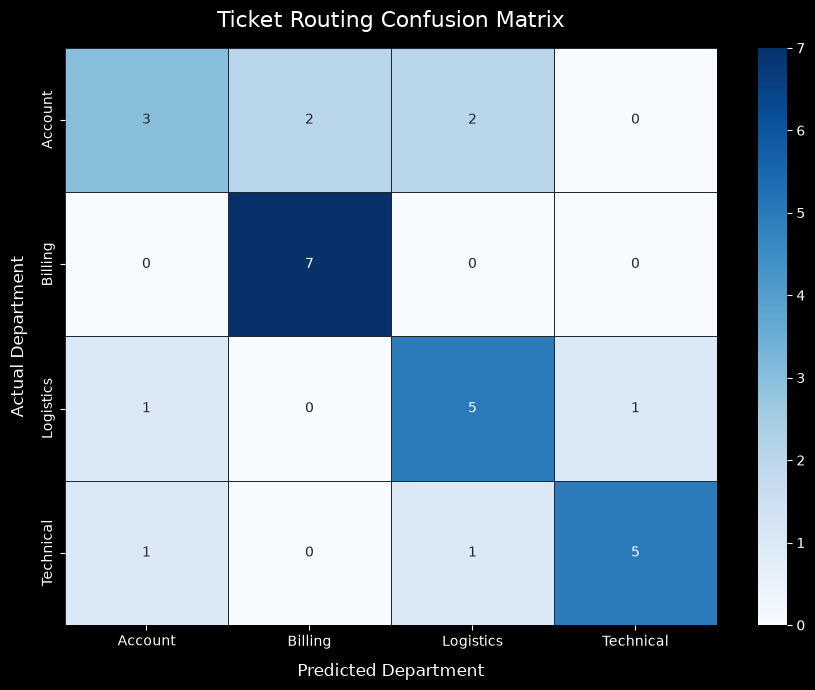

In [ ]:
def train_and_save_model(X_train, y_train):
    print("--- STARTING TRAINING PIPELINE ---")
    print(f"[+] Loaded {len(X_train)} training tickets.")

    # preprocess
    tokenized_corpus = [preprocess_text(text) for text in X_train]
    print("[+] Text preprocessing complete.")

    # Vectorize
    vectorizer = ScratchTfidfVectorizer()
    X_train_vec = vectorizer.fit_transform(tokenized_corpus)
    print(
        f"[+] TF-IDF Vectorizer trained. Vocabulary size: {len(vectorizer.vocab)} words."
    )

    # Train Model
    model = ScratchMultinomialNB(alpha=1.0)
    model.fit(X_train_vec, y_train)
    print("[+] Naive Bayes model trained with Laplace Smoothing.")

    # Save to disk in the models/ folder
    os.makedirs("models", exist_ok=True)

    with open("models/custom_tfidf_vectorizer.pkl", "wb") as f:
        pickle.dump(vectorizer, f)

    with open("models/custom_naive_bayes_model.pkl", "wb") as f:
        pickle.dump(model, f)

    print("[+] Model and Vectorizer successfully saved to disk as .pkl files!\n")
    return vectorizer, model


def evaluate_model(vectorizer, model, X_test, y_test):
    print("STARTING EVALUATION ")
    print(f"[+] Evaluating model on {len(X_test)} unseen test tickets...")

    tokenized_test = [preprocess_text(text) for text in X_test]
    X_test_vec = vectorizer.transform(tokenized_test)

    predictions = model.predict(X_test_vec)

    acc = accuracy_score(y_test, predictions)
    print(f"\n[=>] MODEL ACCURACY: {acc * 100:.2f}%")

    print("\nClassification Report ")
    print(classification_report(y_test, predictions))

    cm = confusion_matrix(y_test, predictions, labels=model.classes)

    # Apply a dark theme to the plot to match your UI
    plt.style.use("dark_background")
    plt.figure(figsize=(9, 7))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=model.classes,
        yticklabels=model.classes,
        linewidths=0.5,
        linecolor="#1f2833",
    )

    plt.title("Ticket Routing Confusion Matrix", fontsize=16, pad=15)
    plt.xlabel("Predicted Department", fontsize=12, labelpad=10)
    plt.ylabel("Actual Department", fontsize=12, labelpad=10)
    plt.tight_layout()

    # Save the plot as an image
    plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
    print("[+] Confusion matrix plot saved as 'confusion_matrix.png'")

    # Show the plot window
    plt.show()


def main():

    raw_texts = [item[0] for item in TRAINING_DATA]
    labels = [item[1] for item in TRAINING_DATA]

    X_train, X_test, y_train, y_test = train_test_split(
        raw_texts, labels, test_size=0.2, random_state=42, stratify=labels
    )

    vectorizer, model = train_and_save_model(X_train, y_train)

    evaluate_model(vectorizer, model, X_test, y_test)


if __name__ == "__main__":
    main()